## Transfer Learning with MobileNetV3-Small

Use a pretrained MobileNetV3-Small model trained on ImageNet as a feature extractor for GTSRB traffic sign classification.

## Library

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.utils import image_dataset_from_directory

In [3]:
TRAIN_DIR = Path("./data/raw/Train")
TEST_DIR = Path("./data/processed/Test")

MODEL_DIR = Path("./models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")

Image size: (224, 224)
Batch size: 32


## Create train & validation for Training

In [6]:
train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=SEED
)

val_ds = image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=SEED
)

test_ds = image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 39209 files belonging to 43 classes.
Using 31368 files for training.


I0000 00:00:1789485540.087433    1203 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789485540.089557    1203 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 39209 files belonging to 43 classes.
Using 7841 files for validation.
Found 12630 files belonging to 43 classes.


In [7]:
print(f"Train samples: {tf.data.experimental.cardinality(train_ds).numpy() * BATCH_SIZE}")
print(f"Validation samples: {tf.data.experimental.cardinality(val_ds).numpy() * BATCH_SIZE}")
print(f"Test samples: {tf.data.experimental.cardinality(test_ds).numpy() * BATCH_SIZE}")

Train samples: 31392
Validation samples: 7872
Test samples: 12640


## Classes

In [8]:
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")

Number of classes: 43
Class names: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

## Classes samples

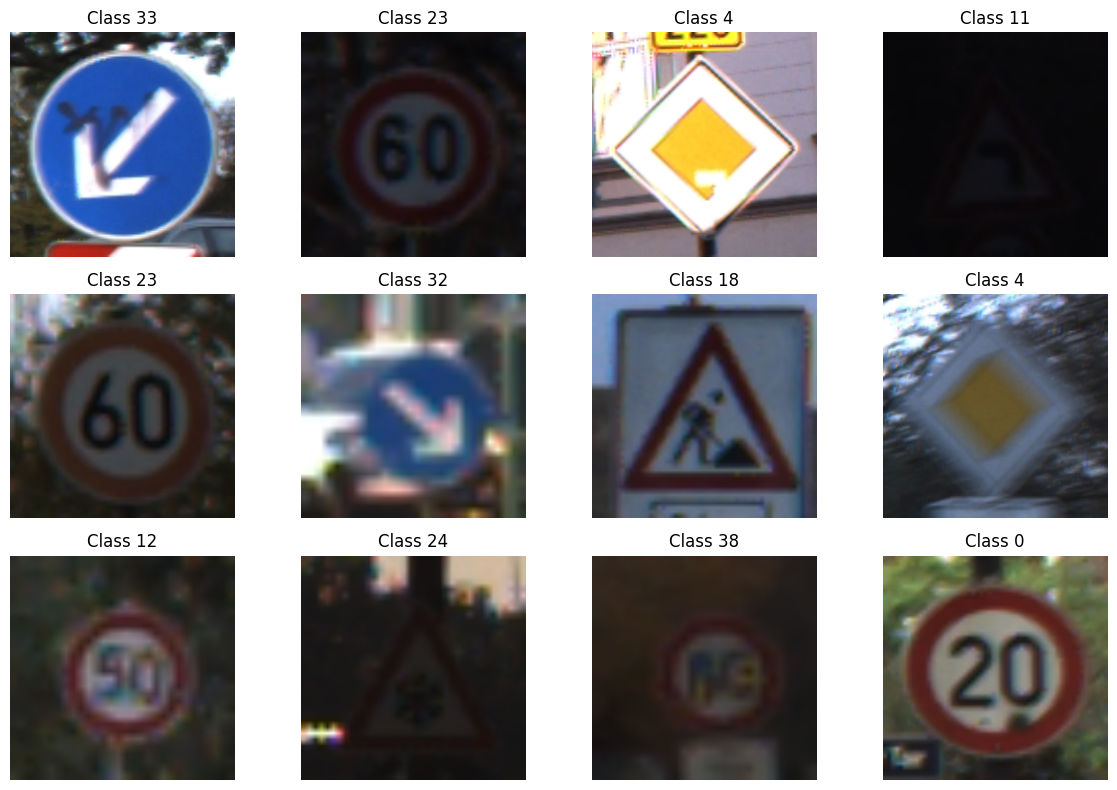

In [10]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 8))

for i in range(12):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(f"Class {labels[i].numpy()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Parameters & Augmentation

In [11]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1),
])

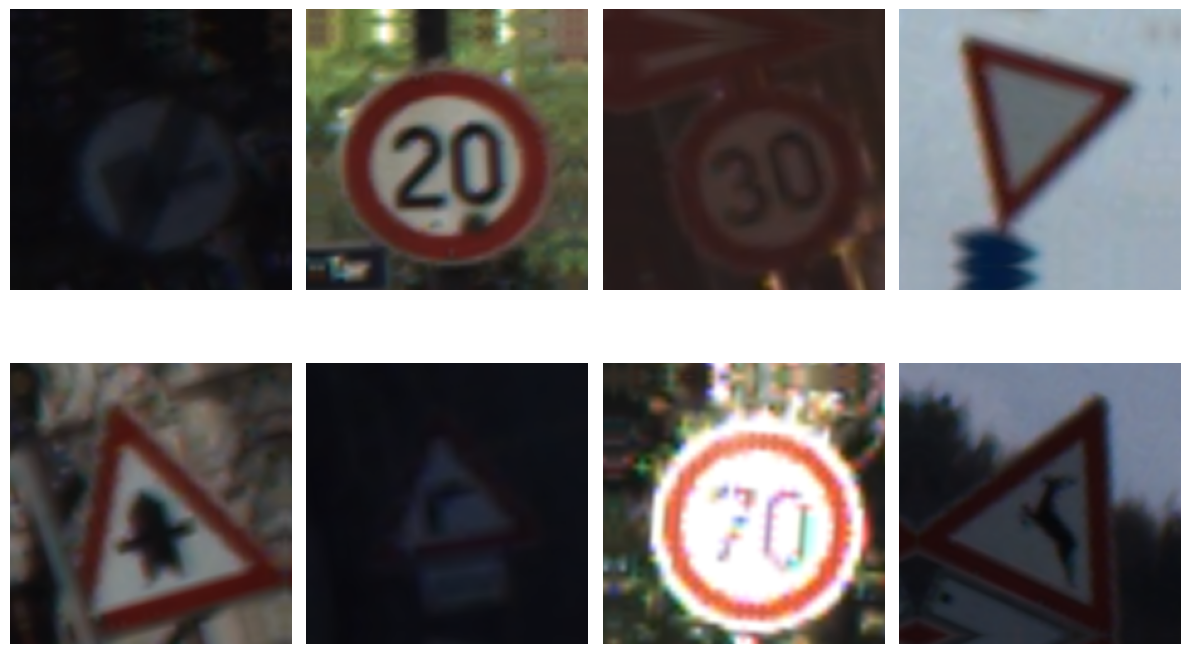

In [12]:
sample_images, _ = next(iter(train_ds))

plt.figure(figsize=(12, 8))

for i in range(8):
    augmented = data_augmentation(sample_images[i:i+1], training=True)

    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(tf.cast(augmented[0], tf.uint8))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
base_model = MobileNetV3Small(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

print(f"Trainable: {base_model.trainable}")
print(f"Parameters: {base_model.count_params():,}")

Trainable: False
Parameters: 939,120


## Train model

In [14]:
# sequential model
model = keras.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(num_classes, activation="softmax")
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (1, 7, 7, 576)         │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (1, 576)               │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 128)               │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 43)                │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,018,523 (3.89 MB)

 Trainable params: 79,403 (310.17 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [15]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
checkpoint_path = MODEL_DIR / "mobilenet_v3_small_best.keras"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_accuracy",
        save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

In [17]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.5558 - loss: 1.4510 - val_accuracy: 0.7551 - val_loss: 0.7376
Epoch 2/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 30s 31ms/step - accuracy: 0.7380 - loss: 0.8013 - val_accuracy: 0.8442 - val_loss: 0.4822
Epoch 3/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 30s 31ms/step - accuracy: 0.7886 - loss: 0.6339 - val_accuracy: 0.8795 - val_loss: 0.3825
Epoch 4/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 30s 31ms/step - accuracy: 0.8208 - loss: 0.5350 - val_accuracy: 0.8954 - val_loss: 0.3306
Epoch 5/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 30s 31ms/step - accuracy: 0.8392 - loss: 0.4760 - val_accuracy: 0.9075 - val_loss: 0.2876
Epoch 6/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 30s 31ms/step - accuracy: 0.8536 - loss: 0.4310 - val_accuracy: 0.9101 - val_loss: 0.2690
Epoch 7/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 30s 31ms/step - accuracy: 0.8641 - loss: 0.4021 - val_accuracy: 0.9180 - val_loss: 0.2542
Epoch 8/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 30s 31ms/step - accuracy: 0.8709 - loss: 0.3823 - 

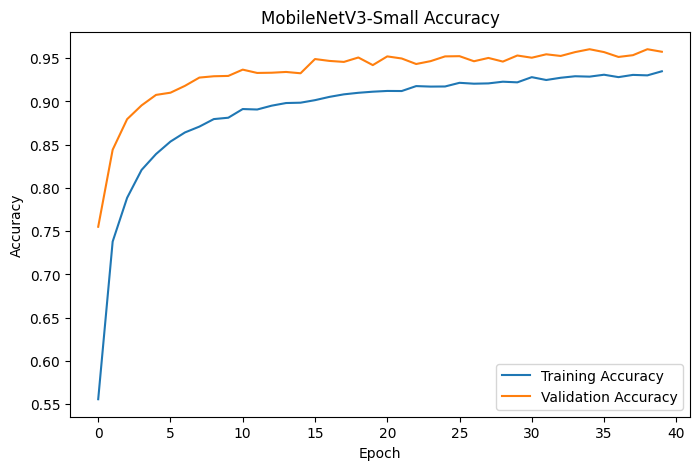

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV3-Small Accuracy")
plt.legend()

plt.show()

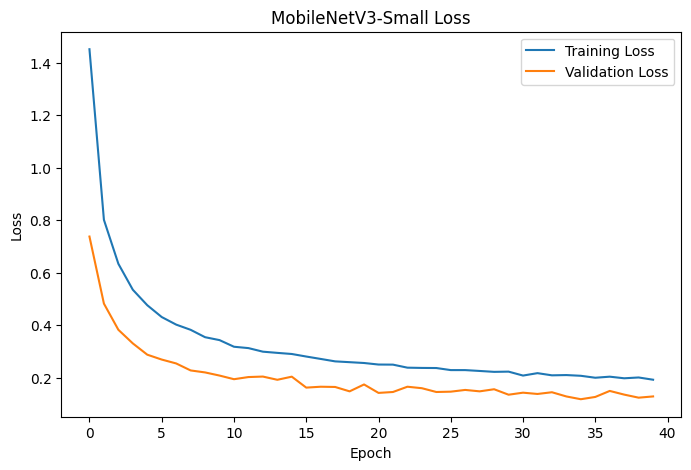

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV3-Small Loss")
plt.legend()

plt.show()

In [20]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Trainable layers: {sum(layer.trainable for layer in base_model.layers)}")

Trainable layers: 30


In [21]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 48s 40ms/step - accuracy: 0.8625 - loss: 0.4621 - val_accuracy: 0.9330 - val_loss: 0.2029
Epoch 2/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 39s 40ms/step - accuracy: 0.9335 - loss: 0.1936 - val_accuracy: 0.9694 - val_loss: 0.0902
Epoch 3/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 38s 39ms/step - accuracy: 0.9517 - loss: 0.1400 - val_accuracy: 0.9753 - val_loss: 0.0752
Epoch 4/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 39s 39ms/step - accuracy: 0.9594 - loss: 0.1139 - val_accuracy: 0.9833 - val_loss: 0.0504
Epoch 5/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 38s 39ms/step - accuracy: 0.9673 - loss: 0.0962 - val_accuracy: 0.9833 - val_loss: 0.0501
Epoch 6/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 38s 39ms/step - accuracy: 0.9702 - loss: 0.0819 - val_accuracy: 0.9880 - val_loss: 0.0356
Epoch 7/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 38s 39ms/step - accuracy: 0.9748 - loss: 0.0738 - val_accuracy: 0.9902 - val_loss: 0.0301
Epoch 8/50
981/981 ━━━━━━━━━━━━━━━━━━━━ 38s 39ms/step - accuracy: 0.9799 - loss: 0.0586 - 

In [23]:
loss, accuracy = model.evaluate(val_ds)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

246/246 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9977 - loss: 0.0066
Validation Loss: 0.0066
Validation Accuracy: 0.9977


## Save model

In [24]:
final_model_path = MODEL_DIR / "mobilenet_v3_small_gtsrb.keras"

model.save(final_model_path)

print(f"Model saved to: {final_model_path}")

Model saved to: models/mobilenet_v3_small_gtsrb.keras
